<a href="https://colab.research.google.com/github/va4756/deeplearn_practice/blob/main/pytorch_reinfoceL_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.char_rnn_classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1_1.기초부터 시작하는 NLP: 문자-단위 RNN으로 이름 생성하기

### 데이터 준비

In [ ]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import unicodedata
import string

In [ ]:
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1  # EOS(end of sentence) 기호 추가

In [ ]:
def findFiles(path): return glob.glob(path)

In [ ]:
# 유니코드 문자열을 ASCII로 변환
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

In [ ]:
# 파일을 읽고 줄 단위로 분리
def readLines(filename):
    with open(filename, encoding='utf-8') as some_file:
        return [unicodeToAscii(line.strip()) for line in some_file]

In [ ]:
# 각 언어의 이름 목록인 category_lines 사전 생성
category_lines = {}
all_categories = []
for filename in findFiles('/content/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

In [ ]:
if n_categories ==0:
    raise RuntimeError('Data not found. Make sure that you downloaded data '
        'from https://download.pytorch.org/tutorial/data.zip and extract it to '
        'the current directory.')

In [ ]:
print('# categories:', n_categories, all_categories)
print(unicodeToAscii("O'Néàl"))

# categories: 18 ['Italian', 'Irish', 'German', 'Dutch', 'Greek', 'Chinese', 'Korean', 'Scottish', 'Portuguese', 'Spanish', 'Vietnamese', 'Arabic', 'Japanese', 'Czech', 'Russian', 'Polish', 'English', 'French']
O'Neal


### 네트워크 생성

In [ ]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category, input, hidden):
        input_combined = torch.cat((category, input, hidden), 1)
        hidden = self.i2h(input_combined)
        output = self.i2o(input_combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

### 학습

In [ ]:
import random

# 목록에서 무작위 아이템 반환
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

In [ ]:
# 임의의 category 및 그 category에서 무작위 줄(이름) 얻기
def randomTrainingPair():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    return category, line

In [ ]:
# Category를 위한 One-hot 벡터
def categoryTensor(category):
    li = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][li] = 1
    return tensor

In [ ]:
# 입력을 위한 처음부터 마지막 문자(EOS 제외)까지의  One-hot 행렬
def inputTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li in range(len(line)):
        letter = line[li]
        tensor[li][0][all_letters.find(letter)] = 1
    return tensor

In [ ]:
# 목표를 위한 두번째 문자 부터 마지막(EOS)까지의 ``LongTensor``
def targetTensor(line):
    letter_indexes = [all_letters.find(line[li]) for li in range(1, len(line))]
    letter_indexes.append(n_letters - 1)  #EOS
    return torch.LongTensor(letter_indexes)

In [ ]:
# 임의의 Category에서 Category, Input, Target Tensor를 만듬
def randomTrainingExample():
    category, line = randomTrainingPair()
    category_tensor = categoryTensor(category)
    input_line_tensor = inputTensor(line)
    target_line_tensor = targetTensor(line)
    return category_tensor, input_line_tensor, target_line_tensor

### 네트워크 학습

In [ ]:
rnn = RNN(n_letters, 128, n_letters)

In [ ]:
criterion = nn.NLLLoss()
learning_rate = 0.0005

def train(category_tensor, input_line_tensor, target_line_tensor):
    target_line_tensor.unsqueeze_(-1)
    hidden = rnn.initHidden()

    rnn.zero_grad()

    loss = torch.Tensor([0])

    for i in range(input_line_tensor.size(0)):
        output, hidden = rnn(category_tensor, input_line_tensor[i], hidden)
        l = criterion(output, target_line_tensor[i])
        loss += l

    loss.backward()

    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=learning_rate)

    return output, loss.item() / input_line_tensor.size(0)

In [ ]:
import math
import time

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

In [ ]:
# n_iters = 100000
n_iters = 10000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0

In [ ]:
start = time.time()

for iter in range(1, n_iters + 1):
    output, loss = train(*randomTrainingExample())
    total_loss += loss

    if iter % print_every == 0:
        print('%s (%d %d%%) %.4f' % (timeSince(start), iter, iter / n_iters * 100, loss))

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

0m 18s (5000 50%) nan
0m 36s (10000 100%) nan


### 손실 도식화

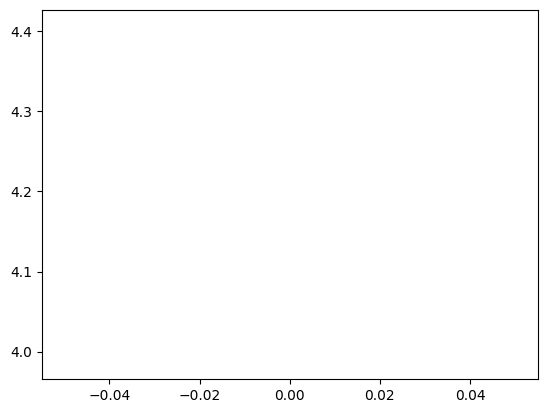

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(all_losses)

### 네트워크 샘플링

In [ ]:
max_length = 20

# 카테고리와 시작 문자로부터 샘플링 하기
def sample(category, start_letter='A'):
    with torch.no_grad():  # 샘플링에서 히스토리를 추적할 필요 없음
        category_tensor = categoryTensor(category)
        input = inputTensor(start_letter)
        hidden = rnn.initHidden()

        output_name = start_letter

        for i in range(max_length):
            output, hidden = rnn(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == n_letters - 1:
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = inputTensor(letter)

        return output_name

In [ ]:
# 하나의 카테고리와 여러 시작 문자들로 여러 개의 샘플 얻기
def samples(category, start_letters='ABC'):
    for start_letter in start_letters:
        print(sample(category, start_letter))

In [ ]:
samples('Russian', 'RUS')

samples('German', 'GER')

samples('Spanish', 'SPA')

samples('Chinese', 'CHI')

RMMMMMMMMMMMMMMMMMMMM
UMMMMMMMMMMMMMMMMMMMM
SMMMMMMMMMMMMMMMMMMMM


# 2.Recurrent DQN: Training recurrent policies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# https://github.com/pytorch/rl/blob/main/tutorials/sphinx-tutorials/dqn_with_rnn.py

In [ ]:
import tempfile

In [ ]:
!pip3 install torchrl
!pip install gymnasium[mujoco]
!pip3 install tqdm

In [ ]:
import gymnasium as gym

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from torch import multiprocessing

if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

In [ ]:
import torch
import tqdm
from tensordict.nn import (
    TensorDictModule as Mod,
    TensorDictSequential,
    TensorDictSequential as Seq,
)
from torch import nn
from torchrl.collectors import Collector
from torchrl.data import LazyMemmapStorage, TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SliceSampler
from torchrl.envs import (
    Compose,
    ExplorationType,
    GrayScale,
    InitTracker,
    ObservationNorm,
    Resize,
    RewardScaling,
    set_exploration_type,
    StepCounter,
    ToTensorImage,
    TransformedEnv,
)
from torchrl.envs.libs.gym import GymEnv
from torchrl.modules import ConvNet, EGreedyModule, LSTMModule, MLP, QValueModule
from torchrl.objectives import DQNLoss, SoftUpdate

In [ ]:
is_fork = multiprocessing.get_start_method() == 'fork'
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
print(device)

cpu


In [ ]:
env = TransformedEnv(
    GymEnv("CartPole-v1", from_pixels=True, device=device),
    Compose(
        ToTensorImage(),
        GrayScale(),
        Resize(84, 84),
        StepCounter(),
        InitTracker(),
        RewardScaling(loc=0.0, scale=0.1),
        ObservationNorm(standard_normal=True, in_keys=["pixels"]),
    ),
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: De

In [ ]:
env.transform[-1].init_stats(1000, reduce_dim=[0, 1, 2], cat_dim=0, keep_dims=[0])
td = env.reset()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Policy
feature = Mod(
    ConvNet(
        num_cells=[32, 32, 64],
        squeeze_output=True,
        aggregator_class=nn.AdaptiveAvgPool2d,
        aggregator_kwargs={"output_size": (1,1)},
        device=device
    ),
    in_keys=["pixels"],
    out_keys=["embed"]
)

In [ ]:
n_cells = feature(env.reset())["embed"].shape[-1]

In [ ]:
# LSTM Module
lstm = LSTMModule(
    input_size=n_cells,
    hidden_size=128,
    device=device,
    in_key="embed",
    out_key="embed"
)

In [ ]:
print("in keys", lstm.in_keys)
print("out keys", lstm.out_keys)

in keys ['embed', 'recurrent_state_h', 'recurrent_state_c', 'is_init']
out keys ['embed', ('next', 'recurrent_state_h'), ('next', 'recurrent_state_c')]


In [ ]:
env.append_transform(lstm.make_tensordict_primer())

TransformedEnv(
    env=GymEnv(env=CartPole-v1, batch_size=torch.Size([]), device=cpu),
    transform=Compose(
            ToTensorImage(keys=['pixels']),
            GrayScale(keys=['pixels']),
            Resize(w=84, h=84, interpolation=InterpolationMode.BILINEAR, keys=['pixels']),
            StepCounter(keys=[]),
            InitTracker(keys=[]),
            RewardScaling(loc=0.0000, scale=0.1000, keys=['reward']),
            ObservationNorm(keys=['pixels']),
            TensorDictPrimer(primers=Composite(
                recurrent_state_h: UnboundedContinuous(
                    shape=torch.Size([1, 128]),
                    space=ContinuousBox(
                        low=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True),
                        high=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True)),
                    device=cpu,
                    dtype=torch.float32,
                    domain=continu

In [ ]:
print(env)

TransformedEnv(
    env=GymEnv(env=CartPole-v1, batch_size=torch.Size([]), device=cpu),
    transform=Compose(
            ToTensorImage(keys=['pixels']),
            GrayScale(keys=['pixels']),
            Resize(w=84, h=84, interpolation=InterpolationMode.BILINEAR, keys=['pixels']),
            StepCounter(keys=[]),
            InitTracker(keys=[]),
            RewardScaling(loc=0.0000, scale=0.1000, keys=['reward']),
            ObservationNorm(keys=['pixels']),
            TensorDictPrimer(primers=Composite(
                recurrent_state_h: UnboundedContinuous(
                    shape=torch.Size([1, 128]),
                    space=ContinuousBox(
                        low=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True),
                        high=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True)),
                    device=cpu,
                    dtype=torch.float32,
                    domain=continu

In [ ]:
# MLP
mlp = MLP(
    out_features=2,
    num_cells = [64, ],
    device=device
)

In [ ]:
mlp[-1].bias.data.fill_(0.0)
mlp = Mod(mlp, in_keys=["embed"], out_keys=["action_value"])

In [ ]:
# Using the Q-Values to select an action
qval = QValueModule(action_space=None, spec=env.action_spec)

In [ ]:
policy = Seq(feature, lstm, mlp, qval)

In [ ]:
exploration_module = EGreedyModule(
    annealing_num_steps=1_000_000, spec=env.action_spec, eps_init=0.2, device=device
)
stoch_policy = TensorDictSequential(
    policy,
    exploration_module,
)

In [ ]:
# Using the model for the loss
policy(env.reset())

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([2]), device=cpu, dtype=torch.int64, is_shared=False),
        action_value: Tensor(shape=torch.Size([2]), device=cpu, dtype=torch.float32, is_shared=False),
        chosen_action_value: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        embed: Tensor(shape=torch.Size([128]), device=cpu, dtype=torch.float32, is_shared=False),
        is_init: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                recurrent_state_c: Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, is_shared=False),
                recurrent_state_h: Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([]),
            device=cpu,
            is_shared=False),

In [ ]:
# DQN Loss
loss_fn = DQNLoss(policy, action_space=env.action_spec, delay_value=True)

In [ ]:
updater = SoftUpdate(loss_fn, eps=0.95)

In [ ]:
optim = torch.optim.Adam(policy.parameters(), lr=3e-4)

In [ ]:
# Collector and replay buffer
buffer_scratch_dir = tempfile.TemporaryDirectory().name

In [ ]:
from functools import cache
rb = TensorDictReplayBuffer(
    storage=LazyMemmapStorage(1_000_000, scratch_dir=buffer_scratch_dir),
    sampler=SliceSampler(
        slice_len=50, end_key=("next", "done"), cache_values=True, strict_length=False
    ),
    batch_size=200,
    prefetch=10,
    transform=lambda td: td.to(device),
)

In [ ]:
collector = Collector(
    env,
    stoch_policy,
    frames_per_batch=50,
    total_frames=200,
    storing_device="cpu",
    replay_buffer=rb,
)

In [ ]:
# Training loop
utd = 16
pbar = tqdm.tqdm(total=collector.total_frames)
longest = 0

traj_lens = []
for i, _ in enumerate(collector):
    pbar.update(collector.frames_per_batch)
    # Only start training once we have enough data in the buffer
    if len(rb) < 1000:
        continue
    for j in range(utd):
        s = rb.sample()
        if i == 0 and j == 0:
            # Let's print the first sample to see the data structure
            print(
                "Let us print the first batch of sampled data from the replay buffer.\n"
                "Pay attention to the key names which will reflect what can be found in this data structure, "
                "in particular: the output of the QValueModule (action_values, action and chosen_action_value),"
                "the 'is_init' key that will tell us if a step is initial or not, and the "
                "recurrent_state keys.\n",
                s,
            )
        loss_vals = loss_fn(s)
        loss_vals["loss"].backward()
        optim.step()
        optim.zero_grad()
    pbar.set_description(
        f"buffer_size: {len(rb)}, loss_val: {loss_vals['loss'].item(): 4.4f}"
    )
    exploration_module.step(collector.frames_per_batch)
    updater.step()

    with set_exploration_type(ExplorationType.DETERMINISTIC), torch.no_grad():
        rollout = env.rollout(10000, stoch_policy)
        traj_lens.append(rollout.get(("next", "step_count")).max().item())

  0%|          | 0/200 [00:00<?, ?it/s]

2026-07-13 19:46:18,305 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([1000000]) shape [END]


100%|██████████| 200/200 [00:03<00:00, 60.65it/s]

In [ ]:
# plot our results
if traj_lens:
    from matplotlib import pyplot as plt

    plt.plot(traj_lens)
    plt.xlabel("Test collection")
    plt.title("Test trajectory lengths")

In [ ]:
# Remove scratch dir
try:
    import shutil

    # Use shutil.rmtree() to delete the directory and all its contents
    shutil.rmtree(buffer_scratch_dir)
    print(f"Directory '{buffer_scratch_dir}' deleted successfully.")
except FileNotFoundError:
    print(f"Directory '{buffer_scratch_dir}' not found.")
except Exception as e:
    print(f"Error deleting directory: {e}")
# sphinx_gallery_end_ignore

Directory '/tmp/tmpi_z9wtg5' deleted successfully.


# 3.Multi-Agent Reinforcement Learning (PPO)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3-1.install

In [ ]:
!pip3 install torchrl
!pip3 install vmas
!pip3 install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.9 MB/s eta 0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260251 sha256=f6caa6e667e17a3613aebd810c0c951ca4e81dae081f5dae58f43f5f5fddb616
  Stored in directory: /root/.cache/pip/wheels/a7/6f/80/31791456a87da225991ef3a80730ff89d3b96fe30ffba64d3a
Successfully built vmas
  Attempting uninstall: gym-notices
    Found existing installation: gym-notices 0.1.0
    Uninstalling gym-notices-0.1.0:
      Successfully uninstalled gym-notices-0.1.0


In [ ]:
# Torch
import torch

# Tensordict modules
from tensordict.nn import set_composite_lp_aggregate, TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import multiprocessing

# Data collection
from torchrl.collectors import Collector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage

# Env
from torchrl.envs import RewardSum, TransformedEnv
from torchrl.envs.libs.vmas import VmasEnv
from torchrl.envs.utils import  check_env_specs

# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor, TanhNormal

# Loss
from torchrl.objectives import ClipPPOLoss, ValueEstimators

# Utils
torch.manual_seed(0)
from matplotlib import pyplot as plt
from tqdm import tqdm

#### Define Hyperparameters

In [ ]:
# Devices
is_fork = multiprocessing.get_start_method() == 'fork'
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

In [ ]:
# Sampling
frames_per_batch = 6_000
n_iters = 5
total_frames = frames_per_batch * n_iters

In [ ]:
# Training
num_epochs = 30
mini_batch_size = 400
lr = 3e-4
max_grad_norm = 1.0

In [ ]:
# PPO
clip_epsilon = 0.2
gamma = 0.99
lmbda = 0.9
entropy_eps = 1e-4

In [ ]:
# disable log-prob aggregation
set_composite_lp_aggregate(False).set()

### Environment

In [ ]:
max_steps = 100
num_vmas_envs = (frames_per_batch // max_steps)
scenario_name = "navigation"
n_agents = 3

In [ ]:
env = VmasEnv(
    scenario=scenario_name,
    num_envs=num_vmas_envs,
    continuous_actions=True,
    max_steps=max_steps,
    device=vmas_device,
    n_agents=n_agents
)

In [ ]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: Composite(
    agents: Composite(
        action: BoundedContinuous(
            shape=torch.Size([60, 3, 2]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, contiguous=True)),
            device=cuda:0,
            dtype=torch.float32,
            domain=continuous),
        device=cuda:0,
        shape=torch.Size([60, 3]),
        data_cls=None),
    device=cuda:0,
    shape=torch.Size([60]),
    data_cls=None)
reward_spec: Composite(
    agents: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([60, 3, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True

In [ ]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('agents', 'action')]
reward_keys: [('agents', 'reward')]
done_keys: ['done', 'terminated']


### Transforms

In [ ]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("agents", "episode_reward")]),
)

In [ ]:
check_env_specs(env)

2026-07-14 05:42:47,423 [torchrl][INFO]    check_env_specs succeeded! [END]


### Rollout

In [ ]:
n_rollout_steps = 5
rollout = env.rollout(n_rollout_steps)
print("rollout of three steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)

rollout of three steps: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 5, 3, 2]), device=cuda:0, dtype=torch.float32, is_shared=True),
                episode_reward: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        final_rew: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        pos_rew: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True)},
                    batch_size=torch.Size([60, 5, 3]),
                    device=cuda:0,
                    is_shared=True),
                observation: Tensor(shape=torch.Size([60, 5, 3, 18]), device=cud

### Policy

In [ ]:
share_parameters_policy = True

# first
policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=env.observation_spec["agents", "observation"].shape[
            -1
        ],  # n_obs_per_agent
        n_agent_outputs=2
        * env.full_action_spec[env.action_key].shape[-1],  # 2 * n_actions_per_agents
        n_agents=env.n_agents,
        centralised=False,  # the policies are decentralised (ie each agent will act from its observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    ),
    NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(


In [ ]:
# second
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "loc"), ("agents", "scale")],
)

In [ ]:
from importlib.metadata import distribution
# third
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec_unbatched,
    in_keys=[("agents", "loc"), ("agents", "scale")],
    out_keys=[env.action_key],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.full_action_spec[env.action_key].space.low,
        "high": env.full_action_spec[env.action_key].space.high
    },
    return_log_prob=True
)

### Critic network

In [ ]:
share_parameters_critic = True
mappo = True

In [ ]:
critic_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["agents", "observation"].shape[-1],
    n_agent_outputs=1,
    n_agents=env.n_agents,
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

In [ ]:
critic = TensorDictModule(
    module=critic_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "state_value")],
)

In [ ]:
print("Running policy:", policy(env.reset()))
print("Running value:", critic(env.reset()))

Running policy: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, is_shared=True),
                action_log_prob: Tensor(shape=torch.Size([60, 3]), device=cuda:0, dtype=torch.float32, is_shared=True),
                episode_reward: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        final_rew: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        pos_rew: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True)},
                    batch_size=torch.Size([60, 3]),
                    device=cuda:0,
                    is_

### Data collector

In [ ]:
collector = Collector(
    env,
    policy,
    device=vmas_device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

/tmp/ipykernel_410/878882941.py:1: FutureWarning: The env passed to Collector is missing transforms required by the policy (InitTracker). From torchrl v0.15 the collector will append them automatically. To enable that behavior now (and silence this warning), pass `auto_register_policy_transforms=True`. To opt out permanently, pass `auto_register_policy_transforms=False`.
  collector = Collector(


### Replay buffer

In [ ]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),
    sampler=SamplerWithoutReplacement(),
    batch_size=mini_batch_size,
)

### Loss function

In [ ]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_eps,
    normalize_advantage=False,
)
loss_module.set_keys(
    reward=env.reward_key,
    action=env.action_key,
    value=("agents", "state_value"),
    done=("agents", "done"),
    terminated=("agents", "terminated"),
)

In [ ]:
loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)
GAE = loss_module.value_estimator

In [ ]:
optim = torch.optim.Adam(loss_module.parameters(), lr)

### Training loop

In [ ]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    tensordict_data.set(
        ("next", "agents", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    tensordict_data.set(
        ("next", "agents", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )

    data_view = tensordict_data.reshape(-1)
    replay_buffer.extend(data_view)

    for _ in range(num_epochs):
        for _ in range(frames_per_batch // mini_batch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()

            torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )

            optim.step()
            optim.zero_grad()

    collector.update_policy_weights_()

    # Logging
    done = tensordict_data.get(("next", "agents", "done"))
    episode_reward_mean = (
        tensordict_data.get(("next", "agents", "episode_reward"))[done].mean().item()
    )
    episode_reward_mean_list.append(episode_reward_mean)
    pbar.set_description(f"episode_reward_mean = {episode_reward_mean}", refresh=False)
    pbar.update()


episode_reward_mean = 0:   0%|          | 0/5 [00:17<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization is performed under the same stream as subsequent forwards. If the mismatch is intentional, you can use torch.autograd.graph.set_warn_on_accumulate_grad_stream_mismatch(False) to suppress this warning. (Triggered internally at /pytorch/torch/csrc

### Results

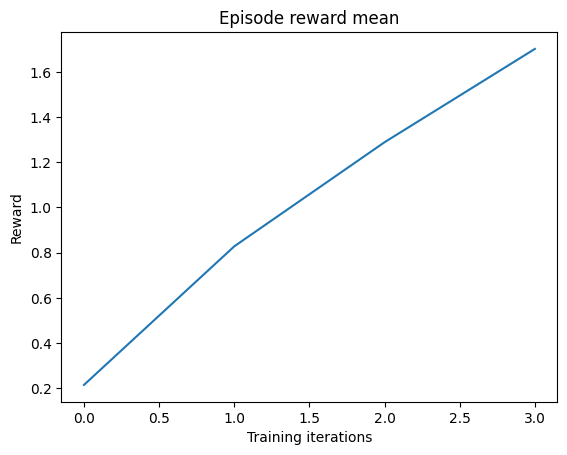

In [ ]:
plt.plot(episode_reward_mean_list)
plt.xlabel("Training iterations")
plt.ylabel("Reward")
plt.title("Episode reward mean")
plt.show()

### colab make image

In [ ]:
# !apt-get update

# !apt-get install -y \
#     xvfb \
#     python3-opengl \
#     libgl1-mesa-glx \
#     libglu1-mesa \
#     freeglut3-dev

In [ ]:
!apt-get update
!apt-get install -y x11-utils
!apt-get install -y xvfb
!pip install pyvirtualdisplay

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


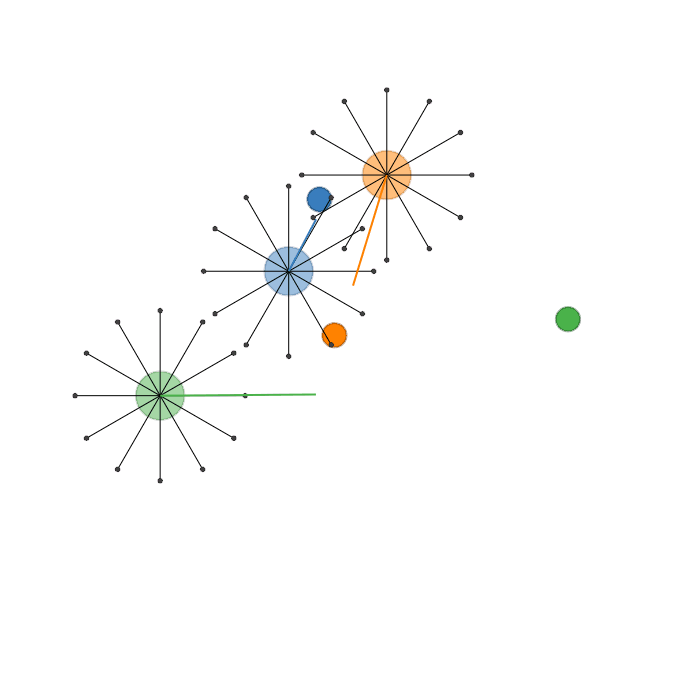

In [ ]:
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()
from PIL import Image

def rendering_callback(env, td):
    # env.frames.append(Image.fromarray(env.render(mode="rgb_array")))
    # 픽셀 렌더링이 비활성화되었으므로 이 콜백은 더 이상 필요하지 않습니다.
    pass

env.frames = []
with torch.no_grad():
    env.rollout(
        max_steps=max_steps,
        policy=policy,
        # callback=rendering_callback, # 픽셀 렌더링이 비활성화되었으므로 콜백을 주석 처리합니다.
        auto_cast_to_device=True,
        break_when_any_done=False,
    )
# 픽셀 렌더링이 비활성화되었으므로 비디오 저장 및 표시 코드도 주석 처리합니다.
# env.frames[0].save(
#     f"{scenario_name}.gif",
#     save_all=True,
#     append_images=env.frames[1:],
#     duration=3,
#     loop=0,
# )

# from IPython.display import Image
# Image(open(f"{scenario_name}.gif", "rb").read())

# 4.pendulum: Writing your environment and transforms with TorchRL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip3 install torchrl
# !pip3 install vmas
# !pip3 install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 33.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from torch import multiprocessing

if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

In [ ]:
from collections import defaultdict

import numpy as np
import torch
import tqdm
from tensordict import TensorDict, TensorDictBase
from tensordict.nn import TensorDictModule
from torch import nn

from torchrl.data import Bounded, Composite, Unbounded
from torchrl.envs import (
    CatTensors,
    EnvBase,
    Transform,
    TransformedEnv,
    UnsqueezeTransform,
)
from torchrl.envs.transforms.transforms import _apply_to_composite
from torchrl.envs.utils import check_env_specs, step_mdp

In [ ]:
DEFAULT_X = np.pi
DEFAULT_Y = 1.0

In [ ]:
def _step(tensordict):
    th, thdot = tensordict["th"], tensordict["thdot"]  # th := theta

    g_force = tensordict["params", "g"]
    mass = tensordict["params", "m"]
    length = tensordict["params", "l"]
    dt = tensordict["params", "dt"]
    u = tensordict["action"].squeeze(-1)
    u = u.clamp(-tensordict["params", "max_torque"], tensordict["params", "max_torque"])
    costs = angle_normalize(th) ** 2 + 0.1 * thdot**2 + 0.001 * (u**2)

    new_thdot = (
        thdot
        + (3 * g_force / (2 * length) * th.sin() + 3.0 / (mass * length**2) * u) * dt
    )
    new_thdot = new_thdot.clamp(
        -tensordict["params", "max_speed"], tensordict["params", "max_speed"]
    )
    new_th = angle_normalize(th + new_thdot * dt)
    reward = -costs.view(*tensordict.shape, 1)
    done = torch.zeros_like(reward, dtype=torch.bool)
    out = TensorDict(
        {
            "th": new_th,
            "thdot": new_thdot,
            "params": tensordict["params"],
            "reward": reward,
            "done": done,
        },
        tensordict.shape,
    )
    return out

In [ ]:
def angle_normalize(x):
    return ((x + torch.pi) % (2 * torch.pi)) - torch.pi

### Resetting the simulator

In [ ]:
def _reset(self, tensordict):
    if tensordict is None or tensordict.is_empty():
        # if no ``tensordict`` is passed, we generate a single set of hyperparameters
        # Otherwise, we assume that the input ``tensordict`` contains all the relevant
        # parameters to get started.
        tensordict = self.gen_params(batch_size=self.batch_size)

    high_th = torch.tensor(DEFAULT_X, device=self.device)
    high_thdot = torch.tensor(DEFAULT_Y, device=self.device)
    low_th = -high_th
    low_thdot = -high_thdot

    # for non batch-locked environments, the input ``tensordict`` shape dictates the number
    # of simulators run simultaneously. In other contexts, the initial
    # random state's shape will depend upon the environment batch-size instead.
    th = (
        torch.rand(tensordict.shape, generator=self.rng, device=self.device)
        * (high_th - low_th)
        + low_th
    )
    thdot = (
        torch.rand(tensordict.shape, generator=self.rng, device=self.device)
        * (high_thdot - low_thdot)
        + low_thdot
    )
    out = TensorDict(
        {
            "th": th,
            "thdot": thdot,
            "params": tensordict["params"],
        },
        batch_size=tensordict.shape,
    )
    return out

### Deterministic reset

In [ ]:
def _make_spec(self, td_params):
    # Under the hood, this will populate self.output_spec["observation"]
    self.observation_spec = Composite(
        th=Bounded(
            low=-torch.pi,
            high=torch.pi,
            shape=(),
            dtype=torch.float32,
        ),
        thdot=Bounded(
            low=-td_params["params", "max_speed"],
            high=td_params["params", "max_speed"],
            shape=(),
            dtype=torch.float32,
        ),
        # we need to add the ``params`` to the observation specs, as we want
        # to pass it at each step during a rollout
        params=make_composite_from_td(td_params["params"]),
        shape=(),
    )
    # since the environment is stateless, we expect the previous output as input.
    # For this, ``EnvBase`` expects some state_spec to be available
    self.state_spec = self.observation_spec.clone()
    # action-spec will be automatically wrapped in input_spec when
    # `self.action_spec = spec` will be called supported
    self.action_spec = Bounded(
        low=-td_params["params", "max_torque"],
        high=td_params["params", "max_torque"],
        shape=(1,),
        dtype=torch.float32,
    )
    self.reward_spec = Unbounded(shape=(*td_params.shape, 1))


In [ ]:
def make_composite_from_td(td):
    composite =  Composite(
        {
            key: make_composite_from_td(tensor)
            if isinstance(tensor, TensorDictBase)
            else Unbounded(dtype=tensor.dtype, device=tensor.device, shape=tensor.shape)
            for key, tensor in td.items()
        }
    )
    return composite

### Reproducible experiments: seeding

In [ ]:
def _set_seed(self, seed: int | None) -> None:
    rng = torch.Generator()
    if seed is not None:
        rng.manual_seed(seed)
    self.rng = rng

### Wrapping things together

In [ ]:
def gen_params(g=10.0, batch_size=None) -> TensorDictBase:
    if batch_size is None:
        batch_size = []
    td = TensorDict(
        {
            "params": TensorDict(
                {
                    "max_speed": 8.0,
                    "max_torque": 2.0,
                    "dt": 0.05,
                    "g": g,
                    "m": 1.0,
                    "l": 1.0
                },
                [],
            )
        },
        [],
    )
    if batch_size:
        td = td.expand(batch_size).contiguous()
    return td

In [ ]:
class PendulumEnv(EnvBase):
    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 30,
    }
    batch_locked = False

    def __init__(self, td_params=None, seed=None, device="cpu"):
        if td_params is None:
            td_params = self.gen_params()

        super().__init__(device=device, batch_size=[])
        self._make_spec(td_params)
        if seed is None:
            seed = torch.empty((), dtype=torch.int64).random_().item()
        self.set_seed(seed)

    # Helpers: _make_step and gen_params
    gen_params = staticmethod(gen_params)
    _make_spec = _make_spec

    # Mandatory methods: _step, _reset and _set_seed
    _reset = _reset
    _step = staticmethod(_step)
    _set_seed = _set_seed


### Testing our environment

In [ ]:
env = PendulumEnv()
check_env_specs(env)

2026-07-15 04:10:33,937 [torchrl][INFO]    check_env_specs succeeded! [END]


In [ ]:
print("observation_spec:", env.observation_spec)
print("state_spec:", env.state_spec)
print("reward_spec:", env.reward_spec)

observation_spec: Composite(
    th: BoundedContinuous(
        shape=torch.Size([]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, contiguous=True),
            high=Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, contiguous=True)),
        device=cpu,
        dtype=torch.float32,
        domain=continuous),
    thdot: BoundedContinuous(
        shape=torch.Size([]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, contiguous=True),
            high=Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, contiguous=True)),
        device=cpu,
        dtype=torch.float32,
        domain=continuous),
    params: Composite(
        max_speed: UnboundedContinuous(
            shape=torch.Size([]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, contiguous=True),
                high=Ten

In [ ]:
td = env.reset()
print("reset tensordict", td)

reset tensordict TensorDict(
    fields={
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        params: TensorDict(
            fields={
                dt: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                g: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                l: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                m: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                max_speed: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                max_torque: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([]),
            device=None,
            is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        th: 

In [ ]:
td = env.rand_step(td)
print("random step tensordict", td)

random step tensordict TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                params: TensorDict(
                    fields={
                        dt: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                        g: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                        l: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                        m: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
                        max_speed: Tensor(shape=torch.Size([]), device=cpu, dtype=torch.float32, is_shared=False),
       

### Transforming an environment

In [ ]:
env = TransformedEnv(
    env,
    # ``Unsqueeze`` the observations that we will concatenate
    UnsqueezeTransform(
        dim=-1,
        in_keys=["th", "thdot"],
        in_keys_inv=["th", "thdot"],
    ),
)

In [ ]:
class SinTransform(Transform):
    def _apply_transform(self, obs: torch.Tensor) -> None:
        return obs.sin()

    # The transform must also modify the data at reset time
    def _reset(
        self, tensordict: TensorDictBase, tensordict_reset: TensorDictBase
    ) -> TensorDictBase:
        return self._call(tensordict_reset)

    # _apply_to_composite will execute the observation spec transform across all
    # in_keys/out_keys pairs and write the result in the observation_spec which
    # is of type ``Composite``
    @_apply_to_composite
    def transform_observation_spec(self, observation_spec):
        return Bounded(
            low=-1,
            high=1,
            shape=observation_spec.shape,
            dtype=observation_spec.dtype,
            device=observation_spec.device,
        )

In [ ]:
class CosTransform(Transform):
    def _apply_transform(self, obs: torch.Tensor) -> None:
        return obs.cos()

    # The transform must also modify the data at reset time
    def _reset(
        self, tensordict: TensorDictBase, tensordict_reset: TensorDictBase
    ) -> TensorDictBase:
        return self._call(tensordict_reset)

    # _apply_to_composite will execute the observation spec transform across all
    # in_keys/out_keys pairs and write the result in the observation_spec which
    # is of type ``Composite``
    @_apply_to_composite
    def transform_observation_spec(self, observation_spec):
        return Bounded(
            low=-1,
            high=1,
            shape=observation_spec.shape,
            dtype=observation_spec.dtype,
            device=observation_spec.device,
        )

In [ ]:
t_sin = SinTransform(in_keys=["th"], out_keys=["sin"])
t_cos = CosTransform(in_keys=["th"], out_keys=["cos"])
env.append_transform(t_sin)
env.append_transform(t_cos)

TransformedEnv(
    env=PendulumEnv(),
    transform=Compose(
            UnsqueezeTransform(dim=-1, in_keys=['th', 'thdot'], out_keys=['th', 'thdot'], in_keys_inv=['th', 'thdot'], out_keys_inv=['th', 'thdot']),
            SinTransform(keys=['th']),
            CosTransform(keys=['th'])))

In [ ]:
cat_transform = CatTensors(
    in_keys=["sin", "cos", "thdot"], dim=-1, out_key="observation", del_keys=False
)
env.append_transform(cat_transform)

TransformedEnv(
    env=PendulumEnv(),
    transform=Compose(
            UnsqueezeTransform(dim=-1, in_keys=['th', 'thdot'], out_keys=['th', 'thdot'], in_keys_inv=['th', 'thdot'], out_keys_inv=['th', 'thdot']),
            SinTransform(keys=['th']),
            CosTransform(keys=['th']),
            CatTensors(in_keys=['cos', 'sin', 'thdot'], out_key=observation)))

In [ ]:
check_env_specs(env)

2026-07-15 04:10:38,606 [torchrl][INFO]    check_env_specs succeeded! [END]


### Executing a rollout

In [ ]:
def simple_rollout(steps=100):
    # preallocate:
    data = TensorDict(batch_size=[steps])
    # reset
    _data = env.reset()
    for i in range(steps):
        _data["action"] = env.action_spec.rand()
        _data = env.step(_data)
        data[i] = _data
        _data = step_mdp(_data, keep_other=True)
    return data

In [ ]:
print("data from rollout:", simple_rollout(100))

data from rollout: TensorDict(
    fields={
        action: Tensor(shape=torch.Size([100, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        cos: Tensor(shape=torch.Size([100, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([100, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                cos: Tensor(shape=torch.Size([100, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([100, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([100, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                params: TensorDict(
                    fields={
                        dt: Tensor(shape=torch.Size([100]), device=cpu, dtype=torch.float32, is_shared=False),
                        g: Tensor(shape=torch.Size([100]), device=cpu, dtype=torch.float32, is_shared=False)

### Batching computations

In [ ]:
batch_size = 10
td = env.reset(env.gen_params(batch_size=[batch_size]))
print("reset (batch size of 10)", td)
td = env.rand_step(td)
print("rand step (batch size of 10)", td)

reset (batch size of 10) TensorDict(
    fields={
        cos: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([10, 3]), device=cpu, dtype=torch.float32, is_shared=False),
        params: TensorDict(
            fields={
                dt: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.float32, is_shared=False),
                g: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.float32, is_shared=False),
                l: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.float32, is_shared=False),
                m: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.float32, is_shared=False),
                max_speed: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.float32, is_shared=False),
                max_torque: Tensor(shape=torch.Size([10]), device=cpu, dtype=torch.floa

In [ ]:
rollout = env.rollout(
    3,
    auto_reset=False,
    tensordict=env.reset(env.gen_params(batch_size=[batch_size])),
)
print("rollout of len 3 (batch size of 10):", rollout)

rollout of len 3 (batch size of 10): TensorDict(
    fields={
        action: Tensor(shape=torch.Size([10, 3, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        cos: Tensor(shape=torch.Size([10, 3, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([10, 3, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                cos: Tensor(shape=torch.Size([10, 3, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([10, 3, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([10, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                params: TensorDict(
                    fields={
                        dt: Tensor(shape=torch.Size([10, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                        g: Tensor(shape=torch.Size([10, 3]), device=cpu, dty

In [ ]:
### Training a simple policy

In [ ]:
torch.manual_seed(0)
env.set_seed(0)

795726461

In [ ]:
net = nn.Sequential(
    nn.LazyLinear(64),
    nn.Tanh(),
    nn.LazyLinear(64),
    nn.Tanh(),
    nn.LazyLinear(64),
    nn.Tanh(),
    nn.LazyLinear(1),
)

In [ ]:
policy = TensorDictModule(
    net,
    in_keys=["observation"],
    out_keys=["action"]
)

In [ ]:
optim = torch.optim.Adam(policy.parameters(), lr=2e-3)

### Training loop

In [ ]:
batch_size = 32
n_iter = 1000
pbar = tqdm.tqdm(range(n_iter // batch_size))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, n_iter)
logs = defaultdict(list)

  0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
for _ in pbar:
    init_td = env.reset(env.gen_params(batch_size=[batch_size]))
    rollout = env.rollout(100, policy, tensordict=init_td, auto_reset=False)
    traj_return = rollout["next", "reward"].mean()
    (-traj_return).backward()
    gn = torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    optim.step()
    optim.zero_grad()
    pbar.set_description(
        f"reward: {traj_return: 4.4f}, "
        f"last reward: {rollout[..., -1]['next', 'reward'].mean(): 4.4f}, gradient norm: {gn: 4.4}"
    )
    logs["return"].append(traj_return.item())
    logs["last_reward"].append(rollout[..., -1]["next", "reward"].mean().item())
    scheduler.step()

reward: -5.8715, last reward: -7.0437, gradient norm:  1.88: 100%|██████████| 31/31 [07:39<00:00, 14.82s/it]


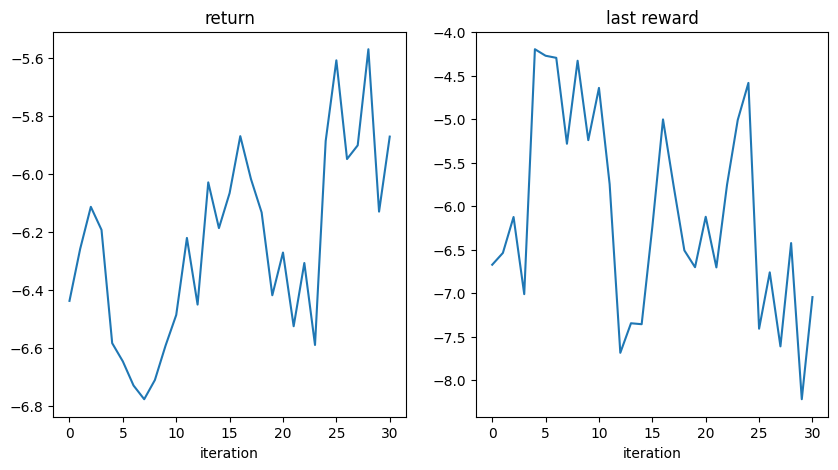

In [ ]:
def plot():
    import matplotlib
    from matplotlib import pyplot as plt

    is_ipython = "inline" in matplotlib.get_backend()
    if is_ipython:
        from IPython import display

    with plt.ion():
        plt.figure(figsize=(10, 5))
        plt.subplot(1,2,1)
        plt.plot(logs["return"])
        plt.title("return")
        plt.xlabel("iteration")

        plt.subplot(1, 2, 2)
        plt.plot(logs["last_reward"])
        plt.title("last reward")
        plt.xlabel("iteration")

        if is_ipython:
            display.display(plt.gcf())
            display.clear_output(wait=True)

        plt.show()

plot()

# 5.MuJoCo scripted manipulation with human-readable robot actions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip3 install torchrl
!pip3 install gymnasium[mujoco]
!pip3 install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 26.8 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import importlib.util
import os

from collections.abc import Iterator

import torch
from tensordict import TensorDict, TensorDictBase
from torchrl.envs import CubeBowlEnv, RobotMacroAction, RobotMacroActionMode, step_mdp
from torchrl.record import VideoRecorder

_has_mujoco = importlib.util.find_spec("mujoco") is not None

if not _has_mujoco:
    raise ImportError("This tutorial requires the `mujoco` Python package.")

In [4]:
!git clone --depth=1 --filter=blob:none --sparse \
    https://github.com/google-deepmind/mujoco_menagerie.git /tmp/menagerie
!git -C /tmp/menagerie sparse-checkout set \
    universal_robots_ur5e robotiq_2f85
!export TORCHRL_MUJOCO_MENAGERIE_PATH=/tmp/menagerie

Cloning into '/tmp/menagerie'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (208/208), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 208 (delta 8), reused 125 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (208/208), 93.51 KiB | 759.00 KiB/s, done.
Resolving deltas: 100% (8/8), done.
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 40.78 KiB | 673.00 KiB/s, done.
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 40 (delta 3), reused 17 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 8.09 MiB | 10.54 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (55/55), done.


In [6]:
import os
os.environ["TORCHRL_MUJOCO_MENAGERIE_PATH"] = "/content/mujoco_menagerie"
MENAGERIE_PATH = os.environ.get(CubeBowlEnv.MENAGERIE_ENV_VAR)
if MENAGERIE_PATH is None:
    raise RuntimeError(
        f"Set {CubeBowlEnv.MENAGERIE_ENV_VAR} to a MuJoCo Menagerie checkout "
        "before running this tutorial."
    )

MAX_EPISODE_STEPS = 12000
RENDER_WIDTH = 480
RENDER_HEIGHT = 360
VIDEO_FRAME_SKIP = 16
VIDEO_INTERVAL_MS = 55
IK_KWARGS = {
    "iterations": 220,
    "orientation_weight": 1.0,
    "step_size": 0.7,
    "damping": 1e-4,
}

In [10]:
import os
import shutil

# Ensure the mujoco_menagerie directory exists and is correctly populated
menagerie_dir = MENAGERIE_PATH # MENAGERIE_PATH is set in a previous cell to '/content/mujoco_menagerie'
if os.path.exists(menagerie_dir):
    print(f"Directory {menagerie_dir} already exists. Attempting to re-clone to ensure integrity.")
    shutil.rmtree(menagerie_dir)
    print(f"Removed existing directory: {menagerie_dir}")
!git clone https://github.com/google-deepmind/mujoco_menagerie.git {menagerie_dir}
print(f"Cloned mujoco_menagerie to: {menagerie_dir}")

env = CubeBowlEnv(
    seed=0,
    max_episode_steps=MAX_EPISODE_STEPS,
    menagerie_path=MENAGERIE_PATH,
    from_pixels=False, # Changed from True to False to avoid OpenGL rendering error
    pixels_only=False,
    render_width=RENDER_WIDTH,
    render_height=RENDER_HEIGHT,
)
assert env.action_spec.shape[-1] == 7
assert env.robot_home_qpos is not None

primitive_control = env.make_urscript_transform(
    execute=True,
    macro_steps=250,
    settle_steps=1600,
    ik_kwargs=IK_KWARGS,
    stack_rewards=True,
    stack_observations=False
)
recorder = VideoRecorder(
    logger=None,
    tag="scripted_macro",
    skip=VIDEO_FRAME_SKIP,
    make_grid=False,
    in_keys=[], # 'pixels' 키가 없으므로 빈 리스트를 전달하여 픽셀 기록을 비활성화합니다.
    missing_tolerance=True, # Add missing_tolerance to prevent KeyError if 'pixels' key is not found
)
env = env.append_transform(recorder)
env = env.append_transform(primitive_control)

cube_width = 2 * env.OBJECT_HALF_SIZE
grasp_width = cube_width - 0.001
gripper_close_command = env.gripper_ctrl_for_width(grasp_width)

workspace_layouts = torch.tensor(
    [
        # Cube in front of the robot, bowl behind it and slightly to the right.
        [[0.44, -0.21], [0.48, 0.10]],
        # Cube on the robot's right-front side, bowl on the left-back side.
        [[0.51, -0.18], [0.39, 0.04]],
        # Cube in front of the robot, bowl on the left-back side.
        [[0.45, -0.20], [0.38, 0.02]],
        # Cube on the robot's right-front side, bowl near the center-back.
        [[0.52, -0.18], [0.45, 0.02]],
    ],
)

def random_scene_reset(rollout_index: int) -> TensorDict:
    layout = workspace_layouts[rollout_index % len(workspace_layouts)]
    cube_xy = layout[0].view(1, 2)
    bowl_xy = layout[1].view(1, 2)
    cube_pos = torch.cat(
        [cube_xy, torch.full_like(cube_xy[..., :1], env.cube_position[2])],
        dim=-1,
    )
    bowl_target_z = env.bowl_position[2] + env.MENAGERIE_BOWL_TARGET_OFFSET[2]
    bowl_pos = torch.cat(
        [bowl_xy, torch.full_like(bowl_xy[..., :1], bowl_target_z)], -1
    )
    return TensorDict(
        {
            "cube_pos": cube_pos.to(dtype=env.dtype, device=env.device),
            "bowl_pos": bowl_pos.to(dtype=env.dtype, device=env.device),
        },
        batch_size=[1],
        device=env.device,
    )

td = env.reset()
assert td["robot_qpos"].shape[-1] == 6
assert env.low_level_action(td["robot_qpos"]).shape[-1] == 7
# assert td["pixels"].shape[:3] == torch.Size([RENDER_HEIGHT, RENDER_WIDTH, 3]) # Pixel assertion commented out as pixels are no longer being rendered

Directory /content/mujoco_menagerie already exists. Attempting to re-clone to ensure integrity.
Removed existing directory: /content/mujoco_menagerie
Cloning into '/content/mujoco_menagerie'...
remote: Enumerating objects: 8192, done.
remote: Counting objects: 100% (1207/1207), done.
remote: Compressing objects: 100% (465/465), done.
remote: Total 8192 (delta 920), reused 751 (delta 742), pack-reused 6985 (from 2)
Receiving objects: 100% (8192/8192), 570.92 MiB | 20.27 MiB/s, done.
Resolving deltas: 100% (2775/2775), done.
Updating files: 100% (3040/3040), done.
Cloned mujoco_menagerie to: /content/mujoco_menagerie


In [11]:
# Policy shape
def get_small_actions(td: TensorDictBase) -> Iterator[RobotMacroAction]:
    joints = td["robot_qpos"].clone()
    joints[..., 0] = joints[..., 0] + 0.35
    yield RobotMacroAction.reach_joints(joints=joints, gripper="open", steps=18)
    yield RobotMacroAction.close_gripper(steps=18)

small_actions = get_small_actions(td)
small_actions = next(small_actions)
td["action"] = small_actions
assert td["action"].mode.shape == torch.Size([1, 1])

In [12]:
# A scripted cube-to-bowl macro
home_qpos = torch.as_tensor(
    env.robot_home_qpos,
    dtype=td["robot_qpos"].dtype,
    device=td["robot_qpos"].device,
).view(1, 6)
policy_state: dict[str, TensorDictBase | torch.Tensor] = {
    "td": td,
    "gripper_quat": td["pinch_quat"].clone(),
}

def pos_at(
    xyz: torch.Tensor, quat: torch.Tensor | None = None
) -> tuple[torch.Tensor, torch.Tensor]:
    if quat is None:
        quat = torch.zeros(xyz.shape[:-1] + (4,), dtype=xyz.dtype, device=xyz.device)
        quat[..., 0] = 1.0
    else:
        quat = quat.to(dtype=xyz.dtype, device=xyz.device).expand(xyz.shape[:-1] + (4,))
    return xyz, quat

In [ ]:
def carry_action(alpha: float, bowl: torch.Tensor) -> RobotMacroAction:
    current_td = policy_state["td"]
    gripper_quat = policy_state["gripper_quat"]
    cube = current_td["cube_pos"].clone()
    carry_start_cube = policy_state["carry_start_cube"]
    pass

In [ ]:
import tempfile

In [ ]:
!pip3 install torchrl
!pip3 install gymnasium[mujoco]
!pip3 install tqdm

In [ ]:
!pip install mujoco

In [ ]:
!git clone --depth=1 --filter=blob:none --sparse \
    https://github.com/google-deepmind/mujoco_menagerie.git /tmp/menagerie
!git -C /tmp/menagerie sparse-checkout set \
    universal_robots_ur5e robotiq_2f85
!export TORCHRL_MUJOCO_MENAGERIE_PATH=/tmp/menagerie

fatal: destination path '/tmp/menagerie' already exists and is not an empty directory.


In [ ]:
from __future__ import annotations

import importlib.util
import os

from collections.abc import Iterator

import torch
from tensordict import TensorDict, TensorDictBase
from torchrl.envs import CubeBowlEnv, RobotMacroAction, RobotMacroActionMode, step_mdp
from torchrl.record import VideoRecorder

_has_mujoco = importlib.util.find_spec("mujoco") is not None

if not _has_mujoco:
    raise ImportError("The tutorial requires 'mujoco' Python package.")

In [ ]:
!git clone https://github.com/google-deepmind/mujoco_menagerie.git

fatal: destination path 'mujoco_menagerie' already exists and is not an empty directory.


In [ ]:
import os

os.environ["TORCHRL_MUJOCO_MENAGERIE_PATH"] = "/content/mujoco_menagerie"

In [ ]:
import os

print(os.environ["TORCHRL_MUJOCO_MENAGERIE_PATH"])

/content/mujoco_menagerie


In [ ]:
MENAGERIE_PATH = os.environ.get(CubeBowlEnv.MENAGERIE_ENV_VAR)
if MENAGERIE_PATH is None:
    raise RuntimeError(
        f"Set {CubeBowlEnv.MENAGERIE_ENV_VAR} to a MuJoCo Menagerie checkout "
        "before running this tutorial."
    )

In [ ]:
MENAGERIE_PATH = os.environ.get(CubeBowlEnv.MENAGERIE_ENV_VAR)
if MENAGERIE_PATH is None:
    raise RuntimeError(
        f"Set {CubeBowlEnv.MENAGERIE_ENV_VAR} to a MuJoCo Menagerie checkout "
        "before running this tutorial."
    )

MAX_EPISODE_STEPS = 12000
RENDER_WIDTH = 480
RENDER_HEIGHT = 360
VIDEO_FRAME_SKIP = 16
VIDEO_INTERVAL_MS = 55
IK_KWARGS = {
    "iterations": 220,
    "orientation_weight": 1.0,
    "step_size": 0.7,
    "damping": 1e-4,
}

### 5-1.RobotMacroAction as the action

In [ ]:
import inspect
from torchrl.envs.custom.mujoco.cube_bowl import CubeBowlEnv

print(inspect.getsource(CubeBowlEnv.__init__))

    def __init__(
        self,
        *,
        menagerie_path: str | Path | None = None,
        cube_position: tuple[float, float, float] | None = None,
        bowl_position: tuple[float, float, float] | None = None,
        placement_tolerance: float = 0.06,
        terminate_on_success: bool = False,
        backend: Literal["mujoco-torch", "mjx", "mujoco"] = "mujoco",
        **kwargs,
    ) -> None:
        default_cube_position = self.MENAGERIE_CUBE_POSITION
        default_bowl_position = self.MENAGERIE_BOWL_POSITION
        self._gripper_qpos_dim = self.MENAGERIE_GRIPPER_QPOS_DIM
        self._pinch_site_name = self.MENAGERIE_PINCH_SITE_NAME
        self._bowl_target_offset = self.MENAGERIE_BOWL_TARGET_OFFSET
        self._robot_home_qpos = self.MENAGERIE_HOME_QPOS
        self._menagerie_path = self._resolve_menagerie_path(menagerie_path)
        if cube_position is None:
            cube_position = default_cube_position
        if bowl_position is None:
            bowl_

In [ ]:
env = CubeBowlEnv(
    seed=0,
    max_episode_steps=MAX_EPISODE_STEPS,
    menagerie_path=MENAGERIE_PATH,
    from_pixels=False,
    pixels_only=False,
    render_width=RENDER_WIDTH,
    render_height=RENDER_HEIGHT
)
assert env.action_spec.shape[-1] == 7
assert env.robot_home_qpos is not None

In [ ]:
primitive_control = env.make_urscript_transform(
    execute=True,
    macro_steps=250,
    settle_steps=1600,
    ik_kwargs=IK_KWARGS,
    stack_rewards=True,
    stack_observations=False,
)
recorder = VideoRecorder(
    logger=None,
    tag="scripted_macro",
    skip=VIDEO_FRAME_SKIP,
    make_grid=False,
    in_keys=[], # 'pixels' 키가 없으므로 빈 리스트를 전달하여 픽셀 기록을 비활성화합니다.
)
env = env.append_transform(recorder)
env = env.append_transform(primitive_control)

In [ ]:
cube_width = 2 * env.OBJECT_HALF_SIZE
grasp_width = cube_width - 0.001
gripper_close_command = env.gripper_ctrl_for_width(grasp_width)

In [ ]:
workspace_layouts = torch.tensor(
    [
        # Cube in front of the robot, bowl behind it and slightly to the right.
        [[0.44, -0.21], [0.48, 0.10]],
        # Cube on the robot's right-front side, bowl on the left-back side.
        [[0.51, -0.18], [0.39, 0.04]],
        # Cube in front of the robot, bowl on the left-back side.
        [[0.45, -0.20], [0.38, 0.02]],
        # Cube on the robot's right-front side, bowl near the center-back.
        [[0.52, -0.18], [0.45, 0.02]],
    ],
)

In [ ]:
def random_scene_reset(rollout_index: int) -> TensorDict:
    layout = workspace_layouts[rollout_index % len(workspace_layouts)]
    cube_xy = layout[0].view(1, 2)
    bowl_xy = layout[1].view(1, 2)
    cube_pos = torch.cat(
        [cube_xy, torch.full_like(cube_xy[..., :1], env.cube_position[2])],
        dim=-1,
    )
    bowl_target_z = env.bowl_position[2] + env.MENAGERIE_BOWL_TARGET_OFFSET[2]
    bowl_pos = torch.cat(
        [bowl_xy, torch.full_like(bowl_xy[..., :1], bowl_target_z)], -1
    )
    return TensorDict(
        {
            "cube_pos": cube_pos.to(dtype=env.dtype, device=env.device),
            "bowl_pos": bowl_pos.to(dtype=env.dtype, device=env.device),
        },
        batch_size=[1],
        device=env.device,
    )

In [ ]:
td = env.reset()
assert td["robot_qpos"].shape[-1] == 6
assert env.low_level_action(td["robot_qpos"]).shape[-1] == 7
# assert td["pixels"].shape[-3:] == torch.Size([RENDER_HEIGHT, RENDER_WIDTH, 3])